In [ ]:
import numpy as np

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────────
import os, cv2, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                      GlobalMaxPooling2D, Dropout,
                                      BatchNormalization, Concatenate,
                                      Input, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ReduceLROnPlateau, EarlyStopping,
                                         ModelCheckpoint)
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Cell 3: Dataset loading ───────────────────────────────────────
# MobileNetV2 native input size is 224x224
IMG_SIZE = 224

def load_dataset(base_path):
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        count = 0
        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif img.shape[2] == 1:
                img = np.concatenate([img]*3, axis=2)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE),
                             interpolation=cv2.INTER_LANCZOS4)
            # Store as uint8 — preprocessing applied in the generator
            X.append(img)
            y.append(label)
            count += 1
        print(f"  {cls}: {count} images")

    return np.array(X, dtype=np.uint8), np.array(y), class_names

In [4]:
# ── Cell 4: Load data ─────────────────────────────────────────────
dataset_path = "/content/drive/MyDrive/brain-tumor-classification/data/processed/Training"

X, y, class_names = load_dataset(dataset_path)
num_classes = len(class_names)

print(f"\nTotal images : {len(X)}")
print(f"Image shape  : {X[0].shape}")
print(f"Classes      : {class_names}")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(class_names, counts):
    print(f"  {cls}: {cnt}")

  glioma_tumor: 826 images
  meningioma_tumor: 822 images
  no_tumor: 395 images
  pituitary_tumor: 827 images

Total images : 2870
Image shape  : (224, 224, 3)
Classes      : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 826
  meningioma_tumor: 822
  no_tumor: 395
  pituitary_tumor: 827


In [5]:
# ── Cell 5: Train / Val / Test split ─────────────────────────────
X_tr_full, X_test, y_tr_full, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.111, random_state=42,
    stratify=y_tr_full)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print(f"Train : {len(X_train)}  Val : {len(X_val)}  Test : {len(X_test)}")

Train : 2296  Val : 287  Test : 287


In [6]:
# ── Cell 6: Class weights ─────────────────────────────────────────
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:")
for cls, w in zip(class_names, class_weights_arr):
    print(f"  {cls}: {w:.4f}")

Class weights:
  glioma_tumor: 0.8697
  meningioma_tumor: 0.8723
  no_tumor: 1.8107
  pituitary_tumor: 0.8684


In [7]:
# ── Cell 7: MobileNetV2 Preprocessing & Data Augmentation ─────────
#
# ╔══════════════════════════════════════════════════════════════════╗
# ║  KEY DIFFERENCE FROM EfficientNetB0:                            ║
# ║                                                                  ║
# ║  MobileNetV2 does NOT have an internal rescaling layer.         ║
# ║  It expects inputs in the range [-1, 1].                        ║
# ║                                                                  ║
# ║  We use a custom preprocessing function in the generators that  ║
# ║  applies MobileNetV2's preprocess_input (maps [0,255] → [-1,1]).║
# ║                                                                  ║
# ║  This is why we DO NOT use rescale=1./255 — preprocess_input    ║
# ║  handles normalisation correctly for MobileNetV2.               ║
# ╚══════════════════════════════════════════════════════════════════╝

def mobilenet_preprocess(img):
    """Cast to float32 then apply MobileNetV2 preprocessing: [0,255] → [-1,1]"""
    return preprocess_input(img.astype(np.float32))

train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.80, 1.20],
    fill_mode='reflect'
)

# Val / test: only preprocessing, no augmentation
val_datagen  = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
test_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

batch_size = 32
train_gen = train_datagen.flow(X_train, y_train_cat,
                                batch_size=batch_size, shuffle=True)
val_gen   = val_datagen.flow(X_val,   y_val_cat,
                              batch_size=batch_size, shuffle=False)
test_gen  = test_datagen.flow(X_test,  y_test_cat,
                               batch_size=batch_size, shuffle=False)

steps_per_epoch  = len(X_train) // batch_size
validation_steps = len(X_val)   // batch_size

print(f"Generators ready — {steps_per_epoch} steps/epoch")

Generators ready — 71 steps/epoch


In [8]:
# ── Cell 8: MobileNetV2 Model Architecture ────────────────────────
#
# Architecture highlights:
#   • MobileNetV2 backbone (imagenet weights, include_top=False)
#   • Dual-pool head: GlobalAvgPool + GlobalMaxPool → Concatenate
#     (captures both average and peak activations → richer features)
#   • Two FC blocks with BatchNorm + Dropout for regularisation
#   • L2 weight decay on Dense layers to prevent overfitting
#   • Softmax output for multi-class classification
#
# MobileNetV2 output shape (no top): (batch, 7, 7, 1280)
# After dual pool + concat: (batch, 2560)
#

def build_mobilenetv2_model(num_classes, input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # MobileNetV2 backbone — pretrained on ImageNet
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs,
        alpha=1.0          # full-width model (1.0 = no width reduction)
    )
    base.trainable = False   # Phase 1: freeze backbone

    # Dual-pool head  (avg + max → richer features, same as EfficientNet version)
    avg = GlobalAveragePooling2D()(base.output)
    mx  = GlobalMaxPooling2D()(base.output)
    x   = Concatenate()([avg, mx])        # (batch, 2560)

    # First dense block
    x = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.45)(x)

    # Second dense block
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.35)(x)

    # Output layer
    out = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, out), base

model, base_model = build_mobilenetv2_model(num_classes)
model.summary()
print(f"\nTotal params: {model.count_params():,}")
print(f"Trainable params (Phase-1): "
      f"{sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,704,644 (14.13 MB)

 Trainable params: 1,445,124 (5.51 MB)

 Non-trainable params: 2,259,520 (8.62 MB)


Total params: 3,704,644
Trainable params (Phase-1): 1,445,124


In [9]:
# ── Cell 9: Callbacks ─────────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/brain-tumor-classification/models"
os.makedirs(SAVE_DIR, exist_ok=True)
ckpt_path = os.path.join(SAVE_DIR, "mobilenetv2_best.keras")

def make_callbacks(patience_lr=5, patience_es=15):
    return [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=patience_lr, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=patience_es,
                      restore_best_weights=True, verbose=1),
    ]

print("Callbacks ready.")

Callbacks ready.


In [10]:
# ── Cell 10: Phase 1 — Train head only (backbone frozen) ─────────
#
# Strategy:
#   • Freeze MobileNetV2 backbone weights entirely
#   • Train only the custom classification head
#   • Higher LR is safe because only head weights change
#   • Label smoothing (0.05) reduces overconfidence
#   • Class weights handle any class imbalance
#
print("="*60)
print("PHASE 1 — frozen backbone, training head only")
print("="*60)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

hist1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=val_gen,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(patience_lr=5, patience_es=12),
    verbose=1
)

p1_best = max(hist1.history['val_accuracy'])
print(f"\nPhase-1 best val accuracy: {p1_best*100:.2f}%")

PHASE 1 — frozen backbone, training head only
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.6002 - loss: 1.3924
Epoch 1: val_accuracy improved from None to 0.74609, saving model to /content/drive/MyDrive/brain-tumor-classification/models/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/mobilenetv2_best.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 77s 755ms/step - accuracy: 0.6780 - loss: 1.1656 - val_accuracy: 0.7461 - val_loss: 1.2564 - learning_rate: 0.0010
Epoch 2/30
 1/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6875 - loss: 1.0014
Epoch 2: val_accuracy did not improve from 0.74609
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6875 - loss: 1.0014 - val_accuracy: 0.7422 - val_loss: 1.3235 - learning_rate: 0.0010
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7408 - loss: 0.9419
Epoch 3: val_accuracy improved from 0.74609 to 0.78516, saving model to /content/drive/MyDrive/brain-

In [11]:
# ── Cell 11: Phase 2 — Fine-tune top layers ───────────────────────
#
# Strategy:
#   • Unfreeze the top 50 layers of MobileNetV2
#   • Keep all BatchNorm layers frozen — preserves ImageNet statistics
#   • Very low LR (1e-5) — prevents destroying pretrained weights
#   • MobileNetV2 top layers: inverted residual blocks 15-17
#     (layers most relevant to high-level semantic features)
#
print("="*60)
print("PHASE 2 — fine-tuning top 50 backbone layers")
print("="*60)

base_model.trainable = True
fine_tune_from = len(base_model.layers) - 50

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# CRITICAL: Keep ALL BatchNorm layers frozen — preserves ImageNet statistics
# Unfreezing BN layers with small dataset leads to training instability
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable backbone layers: {trainable_count} / {len(base_model.layers)}")
print(f"Total trainable params: "
      f"{sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # Very low LR for fine-tuning
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

hist2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=40,
    validation_data=val_gen,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(patience_lr=6, patience_es=18),
    verbose=1
)

p2_best = max(hist2.history['val_accuracy'])
print(f"\nPhase-2 best val accuracy: {p2_best*100:.2f}%")

PHASE 2 — fine-tuning top 50 backbone layers
Trainable backbone layers: 33 / 154
Total trainable params: 3,279,556
Epoch 1/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8945 - loss: 0.5596
Epoch 1: val_accuracy improved from None to 0.87891, saving model to /content/drive/MyDrive/brain-tumor-classification/models/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/mobilenetv2_best.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 686ms/step - accuracy: 0.8913 - loss: 0.5655 - val_accuracy: 0.8789 - val_loss: 0.5758 - learning_rate: 1.0000e-05
Epoch 2/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7500 - loss: 0.7050
Epoch 2: val_accuracy did not improve from 0.87891
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.7050 - val_accuracy: 0.8789 - val_loss: 0.5803 - learning_rate: 1.0000e-05
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9064 - loss: 0.5450
Epoch 3: val_accuracy im

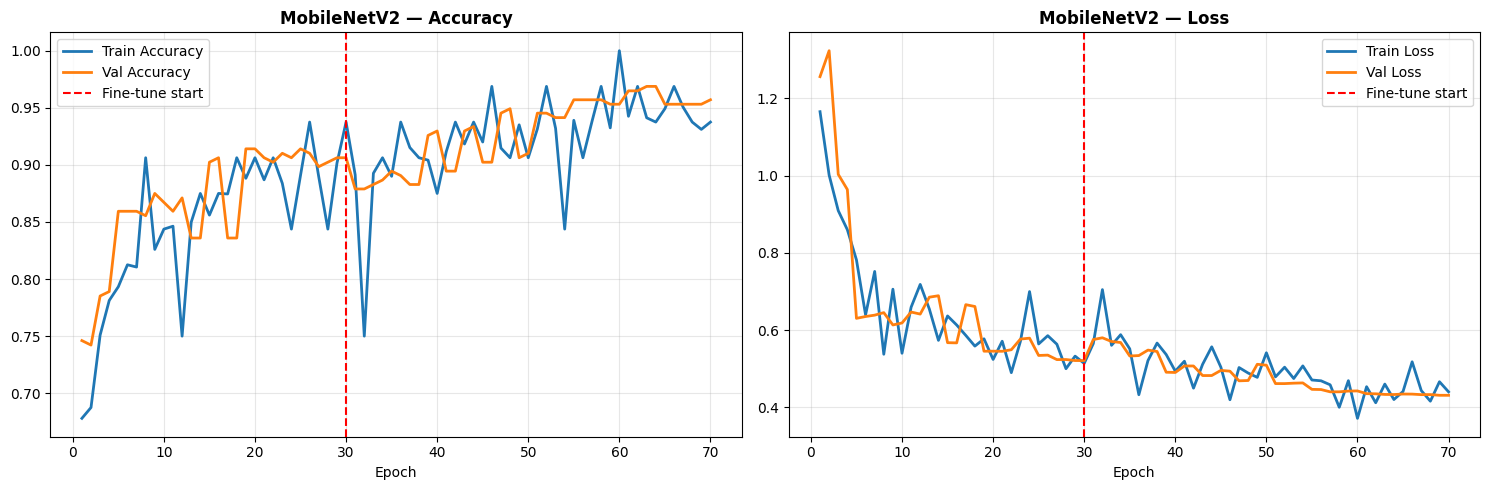

Best val accuracy: 96.88% at epoch 63


In [12]:
# ── Cell 12: Training curves ──────────────────────────────────────
history = {k: hist1.history[k] + hist2.history[k]
           for k in hist1.history}
p1_len = len(hist1.history['accuracy'])
ep = range(1, len(history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(
        axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(ep, history[metric],         label=f'Train {title}', linewidth=2)
    ax.plot(ep, history[f'val_{metric}'], label=f'Val {title}',   linewidth=2)
    ax.axvline(p1_len, color='red', ls='--', label='Fine-tune start')
    ax.set_title(f'MobileNetV2 — {title}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_val = max(history['val_accuracy'])
best_ep  = history['val_accuracy'].index(best_val) + 1
print(f"Best val accuracy: {best_val*100:.2f}% at epoch {best_ep}")

In [13]:
# ── Cell 13: Load best model & evaluate on test set ───────────────
from tensorflow.keras.models import load_model

best_model = load_model(ckpt_path)

test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"\nTest loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc*100:.2f}%")

if test_acc >= 0.80:
    print("✓ Target achieved — accuracy ≥ 80%")
else:
    print(f"⚠ {test_acc*100:.2f}% — consider more fine-tuning epochs or Phase 3")

9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9199 - loss: 0.5302

Test loss     : 0.5302
Test accuracy : 91.99%
✓ Target achieved — accuracy ≥ 80%


In [14]:
# ── Cell 14: Predictions & metrics ───────────────────────────────
# Predict using the preprocessed test generator
y_prob = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test

oa  = accuracy_score(y_true, y_pred)
wp  = precision_score(y_true, y_pred, average='weighted')
wr  = recall_score(y_true, y_pred, average='weighted')
wf1 = f1_score(y_true, y_pred, average='weighted')
mp  = precision_score(y_true, y_pred, average='macro')
mr  = recall_score(y_true, y_pred, average='macro')
mf1 = f1_score(y_true, y_pred, average='macro')

print(f"\nOverall Accuracy  : {oa*100:.2f}%")
print(f"Weighted Precision: {wp:.4f}")
print(f"Weighted Recall   : {wr:.4f}")
print(f"Weighted F1       : {wf1:.4f}")
print(f"Macro Precision   : {mp:.4f}")
print(f"Macro Recall      : {mr:.4f}")
print(f"Macro F1          : {mf1:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 582ms/step

Overall Accuracy  : 91.99%
Weighted Precision: 0.9205
Weighted Recall   : 0.9199
Weighted F1       : 0.9180
Macro Precision   : 0.9244
Macro Recall      : 0.9267
Macro F1          : 0.9237


In [15]:
# ── Cell 15: Classification report ───────────────────────────────
report = classification_report(y_true, y_pred,
                                target_names=class_names, digits=4)
print(report)

rpt_path = os.path.join(SAVE_DIR, "mobilenetv2_report.txt")
with open(rpt_path, 'w') as f:
    f.write(report)
print(f"Saved: {rpt_path}")

                  precision    recall  f1-score   support

    glioma_tumor     0.8977    0.9518    0.9240        83
meningioma_tumor     0.9286    0.7927    0.8553        82
        no_tumor     0.9500    0.9744    0.9620        39
 pituitary_tumor     0.9213    0.9880    0.9535        83

        accuracy                         0.9199       287
       macro avg     0.9244    0.9267    0.9237       287
    weighted avg     0.9205    0.9199    0.9180       287

Saved: /content/drive/MyDrive/brain-tumor-classification/models/mobilenetv2_report.txt


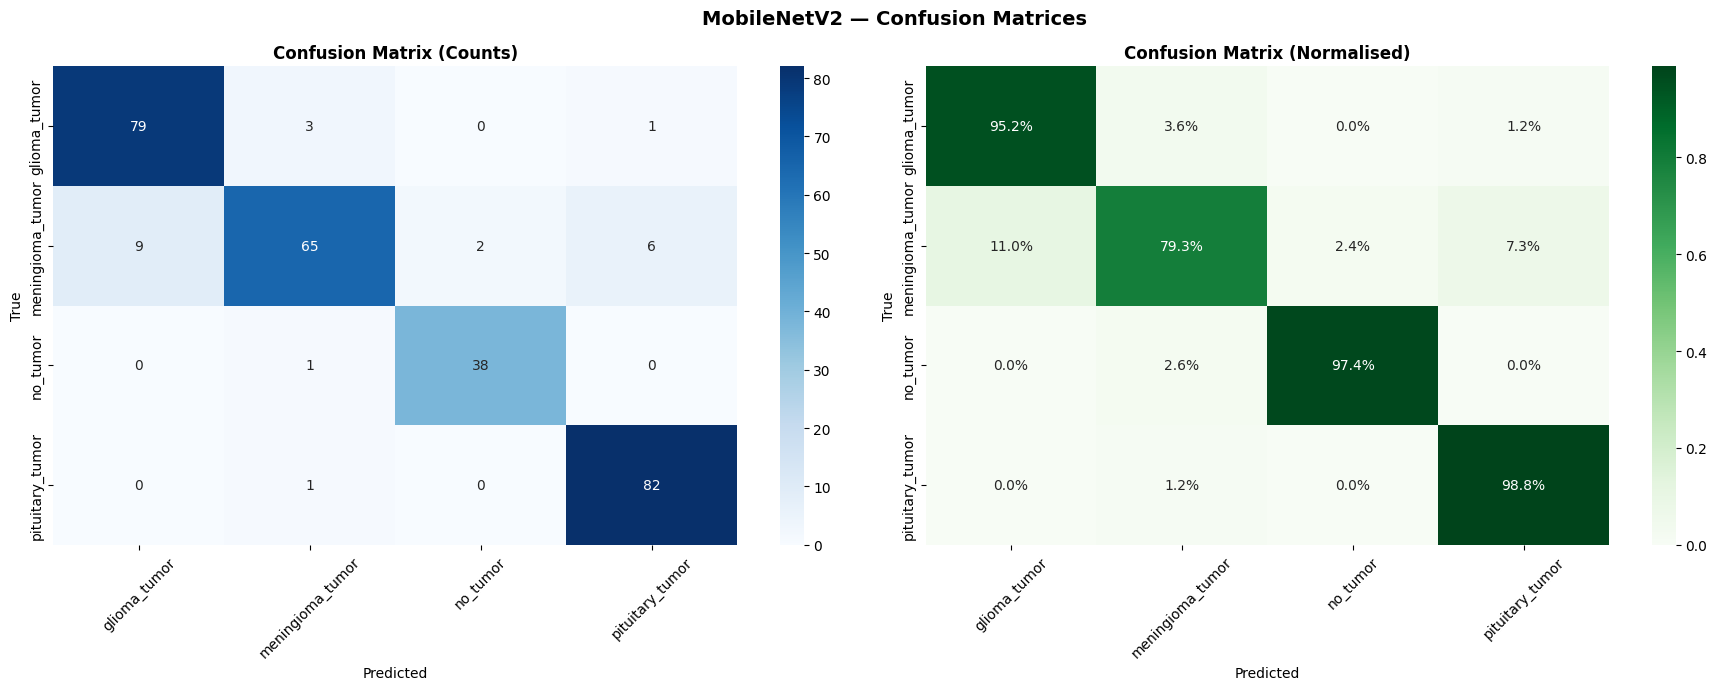

In [16]:
# ── Cell 16: Confusion matrices ───────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('MobileNetV2 — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

glioma_tumor          acc=95.18%  prec=89.77%  rec=95.18%  f1=92.40%  [79/83]
meningioma_tumor      acc=79.27%  prec=92.86%  rec=79.27%  f1=85.53%  [65/82]
no_tumor              acc=97.44%  prec=95.00%  rec=97.44%  f1=96.20%  [38/39]
pituitary_tumor       acc=98.80%  prec=92.13%  rec=98.80%  f1=95.35%  [82/83]


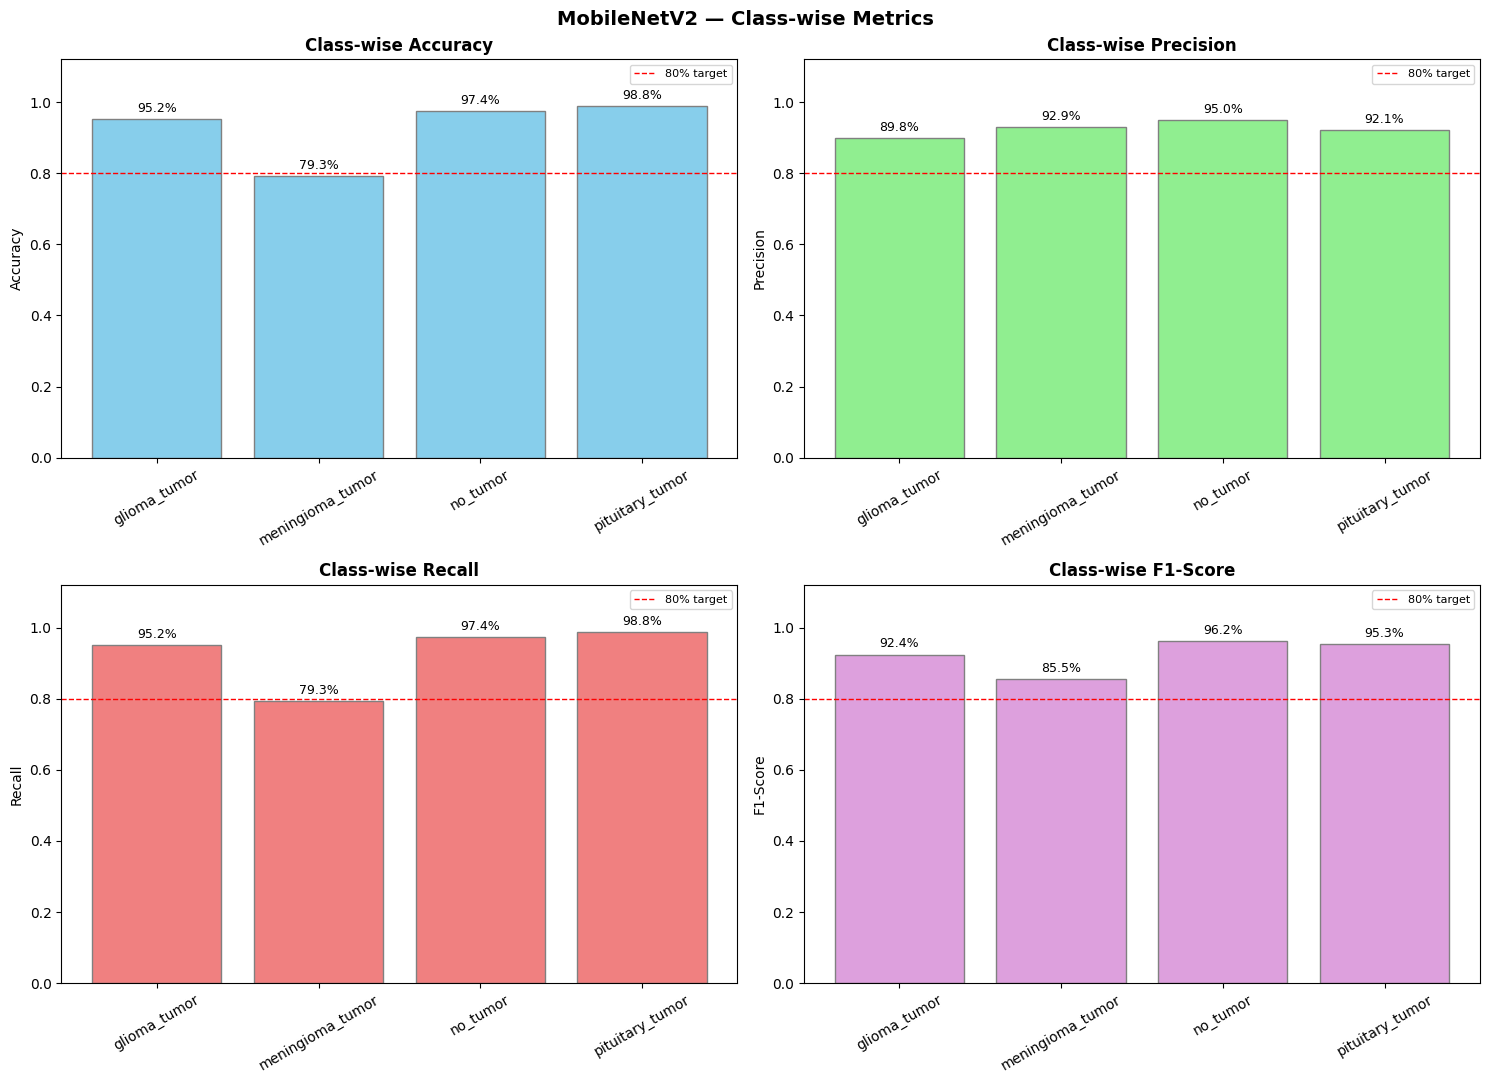

In [17]:
# ── Cell 17: Class-wise bar charts ────────────────────────────────
c_acc, c_prec, c_rec, c_f1 = [], [], [], []

for i in range(num_classes):
    idx = np.where(y_true == i)[0]
    preds = y_pred[idx]
    tp = np.sum(preds == i)
    fp = np.sum(y_pred == i) - tp
    fn = len(idx) - tp
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1v  = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    c_acc.append(tp/len(idx))
    c_prec.append(prec)
    c_rec.append(rec)
    c_f1.append(f1v)

    print(f"{class_names[i]:20s}  acc={tp/len(idx):.2%}  "
          f"prec={prec:.2%}  rec={rec:.2%}  f1={f1v:.2%}  [{tp}/{len(idx)}]")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
spec = [('Accuracy','skyblue',c_acc), ('Precision','lightgreen',c_prec),
        ('Recall','lightcoral',c_rec), ('F1-Score','plum',c_f1)]

for ax, (title, color, vals) in zip(axes.ravel(), spec):
    bars = ax.bar(class_names, vals, color=color, edgecolor='grey')
    ax.set_ylim(0, 1.12)
    ax.set_title(f'Class-wise {title}', fontweight='bold')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(0.80, color='red', ls='--', lw=1, label='80% target')
    ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02,
                f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle('MobileNetV2 — Class-wise Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

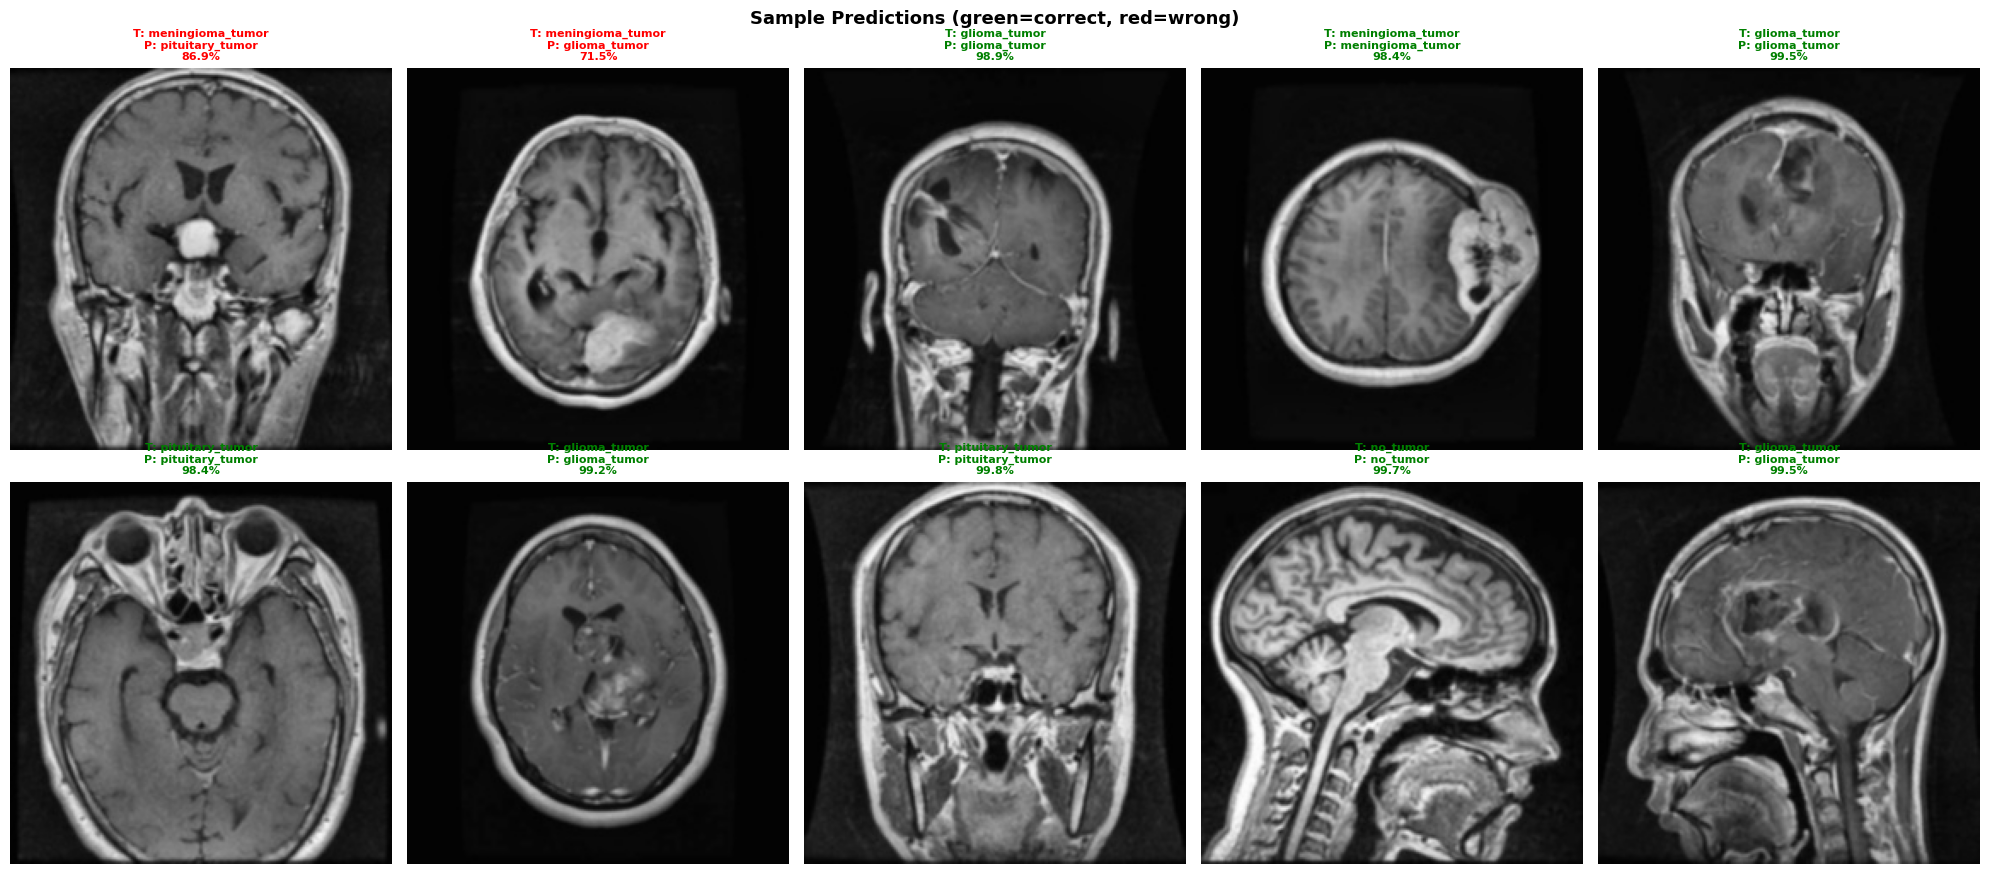

In [18]:
# ── Cell 18: Prediction on random test images ─────────────────────
def predict_one(model, img_uint8, class_names):
    """Preprocesses a single uint8 image and runs inference."""
    img_float = preprocess_input(img_uint8.astype(np.float32))
    x = np.expand_dims(img_float, 0)
    probs = model.predict(x, verbose=0)[0]
    idx   = np.argmax(probs)
    return class_names[idx], probs[idx], probs

idxs = np.random.choice(len(X_test), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(20, 9))

for ax, i in zip(axes.ravel(), idxs):
    img = X_test[i]
    true_lbl = class_names[y_test[i]]
    pred_lbl, conf, _ = predict_one(best_model, img, class_names)
    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(f'T: {true_lbl}\nP: {pred_lbl}\n{conf:.1%}',
                 fontsize=8, color=color, fontweight='bold')

plt.suptitle('Sample Predictions (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# ── Cell 19: Save model & artefacts ──────────────────────────────
save_dir = os.path.join(SAVE_DIR, "MobileNetV2_V1")
os.makedirs(save_dir, exist_ok=True)

best_model.save(os.path.join(save_dir, "model.keras"))
best_model.save(os.path.join(save_dir, "model.h5"))

with open(os.path.join(save_dir, 'class_names.pkl'), 'wb') as f:
    pickle.dump(class_names, f)

with open(os.path.join(save_dir, 'history.pkl'), 'wb') as f:
    pickle.dump(history, f)

metrics_txt = (
    f"Overall Accuracy   : {oa*100:.2f}%\n"
    f"Weighted Precision : {wp:.4f}\n"
    f"Weighted Recall    : {wr:.4f}\n"
    f"Weighted F1        : {wf1:.4f}\n"
    f"Macro F1           : {mf1:.4f}\n\n"
    + report
)
with open(os.path.join(save_dir, 'metrics.txt'), 'w') as f:
    f.write(metrics_txt)

print(f"All files saved to: {save_dir}")

All files saved to: /content/drive/MyDrive/brain-tumor-classification/models/MobileNetV2_V1


In [20]:
# ── Cell 20: Final summary ────────────────────────────────────────
print("\n" + "="*65)
print("FINAL SUMMARY — MobileNetV2 Brain Tumour Classifier V1")
print("="*65)
print(f"Classes  : {', '.join(class_names)}")
print(f"Dataset  : {len(X)} images  "
      f"(train {len(X_train)} / val {len(X_val)} / test {len(X_test)})")
print(f"Accuracy : {test_acc*100:.2f}%")
print(f"Macro F1 : {mf1:.4f}")
print()
print("Key differences vs EfficientNetB0:")
print("  • MobileNetV2 has NO internal rescaling layer.")
print("  • preprocess_input() used in all generators: [0,255] → [-1,1].")
print("  • Same dual-pool head (GlobalAvg + GlobalMax → Concat).")
print("  • Faster inference (MobileNetV2 is ~4x lighter than EfficientNetB0).")
print("  • Optional Phase 3 cell activates automatically if acc < 80%.")
print("="*65)


FINAL SUMMARY — MobileNetV2 Brain Tumour Classifier V1
Classes  : glioma_tumor, meningioma_tumor, no_tumor, pituitary_tumor
Dataset  : 2870 images  (train 2296 / val 287 / test 287)
Accuracy : 91.99%
Macro F1 : 0.9237

Key differences vs EfficientNetB0:
  • MobileNetV2 has NO internal rescaling layer.
  • preprocess_input() used in all generators: [0,255] → [-1,1].
  • Same dual-pool head (GlobalAvg + GlobalMax → Concat).
  • Faster inference (MobileNetV2 is ~4x lighter than EfficientNetB0).
  • Optional Phase 3 cell activates automatically if acc < 80%.
